# Notebook 05: Statistical Analysis
**Purpose:** Prove our EDA findings using formal statistical tests.
Charts show patterns — statistics PROVE them.
**Four tests we run:**
1. Pearson Correlation — how strongly do two variables relate?
2. Independent t-test — is there a significant difference 
   between two groups (e.g. male vs female burnout)?
3. One-Way ANOVA — is there a significant difference across 
   3+ groups (e.g. Year 1 vs Year 2 vs Year 3 vs Year 4)?
4. Linear Regression — which factors best PREDICT burnout?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
df = pd.read_csv('../data/processed/student_health_features.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows")

results_log = []

Dataset loaded: 1,000,000 rows


Pearson Correlation measures the LINEAR relationship 
between two numerical variables. It returns a value r between 
-1 and +1.
  r = +1.0 → perfect positive relationship
  r = 0.0  → no relationship at all
  r = -1.0 → perfect negative relationship
We also get a p-value. If p < 0.05, the correlation is 
STATISTICALLY SIGNIFICANT (not due to random chance).
IMPORTANT: With 1 million rows, almost everything will be 
significant — so we also report Cohen's d and r² to show 
PRACTICAL significance, not just statistical.

TEST 1: PEARSON CORRELATION ANALYSIS
Interpretation guide:
  r > 0.5  = Strong positive correlation
  r 0.3–0.5 = Moderate positive correlation
  r 0.1–0.3 = Weak positive correlation
  r < 0    = Negative correlation (as X goes up, Y goes down)

Business Question                                       r      p-value     r²     Strength  Significant
----------------------------------------------------------------------------------------------------
Does less sleep cause more anxiety?                 0.486       0.0000  0.237     Moderate         YES 
Does less sleep cause more stress?                 -0.260       0.0000  0.068         Weak         YES 
Does more studying increase stress?                 0.349       0.0000  0.122     Moderate         YES 
Does financial pressure drive depression?           0.002       0.5498  0.000   Negligible          No 
Does social support protect against depression?     0.001       0.7901  0.000   Negligible          No 
Does social support reduce o

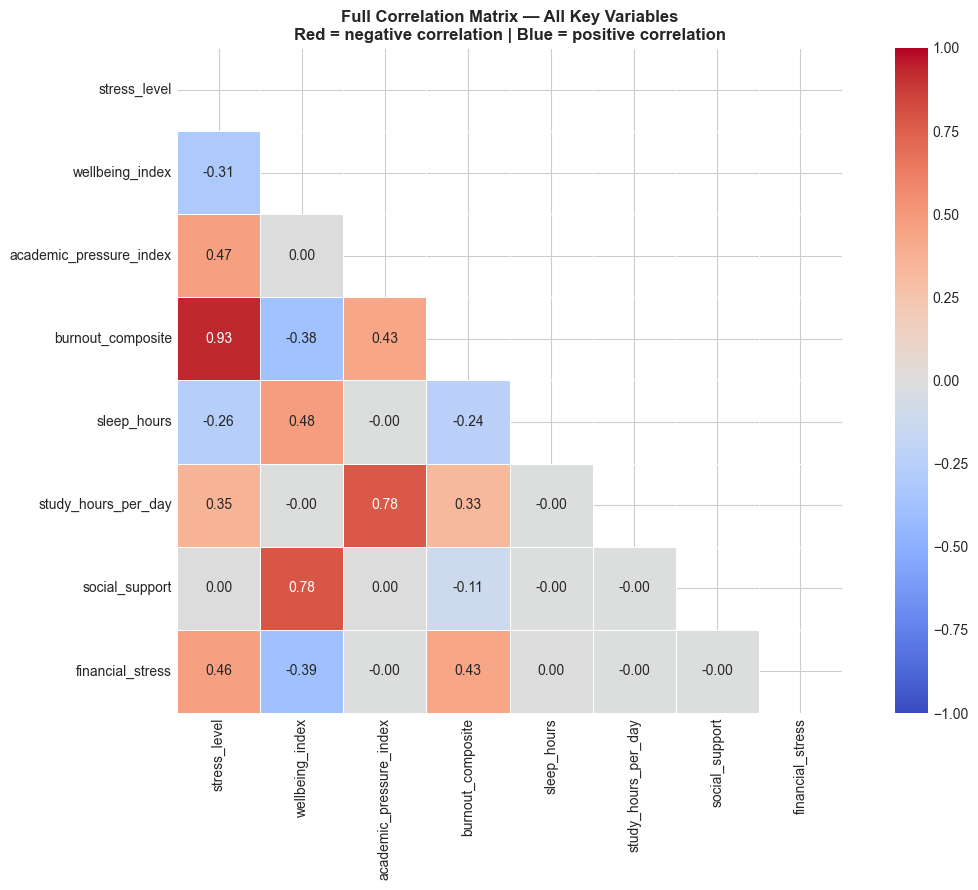

In [2]:
print("=" * 60)
print("TEST 1: PEARSON CORRELATION ANALYSIS")
print("=" * 60)
print("Interpretation guide:")
print("  r > 0.5  = Strong positive correlation")
print("  r 0.3–0.5 = Moderate positive correlation")
print("  r 0.1–0.3 = Weak positive correlation")
print("  r < 0    = Negative correlation (as X goes up, Y goes down)")
print()

correlation_pairs = [
    ('sleep_hours',          'wellbeing_index',     
     'Does less sleep cause more anxiety?'),
    ('sleep_hours',          'stress_level',      
     'Does less sleep cause more stress?'),
    ('study_hours_per_day',  'stress_level',      
     'Does more studying increase stress?'),
    ('financial_stress',     'academic_pressure_index',  
     'Does financial pressure drive depression?'),
    ('social_support',       'academic_pressure_index',  
     'Does social support protect against depression?'),
    ('social_support',       'burnout_composite', 
     'Does social support reduce overall burnout?'),
    ('financial_stress',     'burnout_composite', 
     'Does financial stress increase burnout?'),
    ('study_hours_per_day',  'academic_performance_encoded', 
     'Does more study improve academic performance?'),
]

perf_map = {'Poor':1, 'Average':2, 'Good':3, 'Excellent':4}
df['academic_performance_encoded'] = df['academic_performance'].map(perf_map)

print(f"{'Business Question':<50} {'r':>6} {'p-value':>12} "
      f"{'r²':>6} {'Strength':>12} {'Significant':>12}")
print("-" * 100)

for col1, col2, question in correlation_pairs:
    if col2 not in df.columns:
        continue
    
    sample = df[[col1, col2]].dropna().sample(
        n=min(100000, len(df)), random_state=42
    )
    r, p = pearsonr(sample[col1], sample[col2])
    
    r_squared = r**2
    
    if abs(r) >= 0.5:   strength = "Strong"
    elif abs(r) >= 0.3: strength = "Moderate"
    elif abs(r) >= 0.1: strength = "Weak"
    else:               strength = "Negligible"
    
    significant = "YES " if p < 0.05 else "No "
    direction   = "positive" if r > 0 else "negative"
    
    print(f"{question:<50} {r:>6.3f} {p:>12.4f} "
          f"{r_squared:>6.3f} {strength:>12} {significant:>12}")
    
    results_log.append({
        'test': 'Pearson Correlation',
        'question': question,
        'r': round(r, 3),
        'p': round(p, 4),
        'r2': round(r_squared, 3),
        'significant': p < 0.05
    })

print("\n--- Correlation Matrix Heatmap ---")
num_cols = ['stress_level','wellbeing_index','academic_pressure_index',
            'burnout_composite','sleep_hours','study_hours_per_day',
            'social_support','financial_stress']

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df[num_cols].sample(100000).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Full Correlation Matrix — All Key Variables\n'
             'Red = negative correlation | Blue = positive correlation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/stat_correlation_matrix.png', 
            dpi=150, bbox_inches='tight')
plt.show()

The t-test compares the MEANS of two groups to see 
if the difference is statistically significant.
Question: Do male and female students experience significantly 
different levels of burnout?
H₀ (null hypothesis):    Male and female students have the 
                          SAME average burnout score.
H₁ (alternative):        They have DIFFERENT burnout scores.
If p < 0.05: reject H₀ — the difference IS significant.
We also calculate Cohen's d (effect size) because with 1M rows, 
every tiny difference will have p < 0.05. Cohen's d tells us 
if the difference is MEANINGFUL in the real world.


TEST 2: INDEPENDENT t-TEST — GENDER vs MENTAL HEALTH
H₀: Male and female students have equal mental health scores
H₁: There IS a significant difference between genders

Metric: burnout_composite
  Male mean:      2.836
  Female mean:    2.836
  Difference:     0.001
  t-statistic:    -0.273
  p-value:        0.784804 (Not significant )
  Cohen's d:      -0.001 (Negligible effect)

Metric: wellbeing_index
  Male mean:      5.166
  Female mean:    5.167
  Difference:     0.000
  t-statistic:    -0.164
  p-value:        0.869369 (Not significant )
  Cohen's d:      -0.000 (Negligible effect)

Metric: academic_pressure_index
  Male mean:      5.628
  Female mean:    5.631
  Difference:     0.003
  t-statistic:    -1.107
  p-value:        0.268090 (Not significant )
  Cohen's d:      -0.002 (Negligible effect)

Metric: stress_level
  Male mean:      4.247
  Female mean:    4.246
  Difference:     0.001
  t-statistic:    0.211
  p-value:        0.832526 (Not significant )
  Cohen's d:      

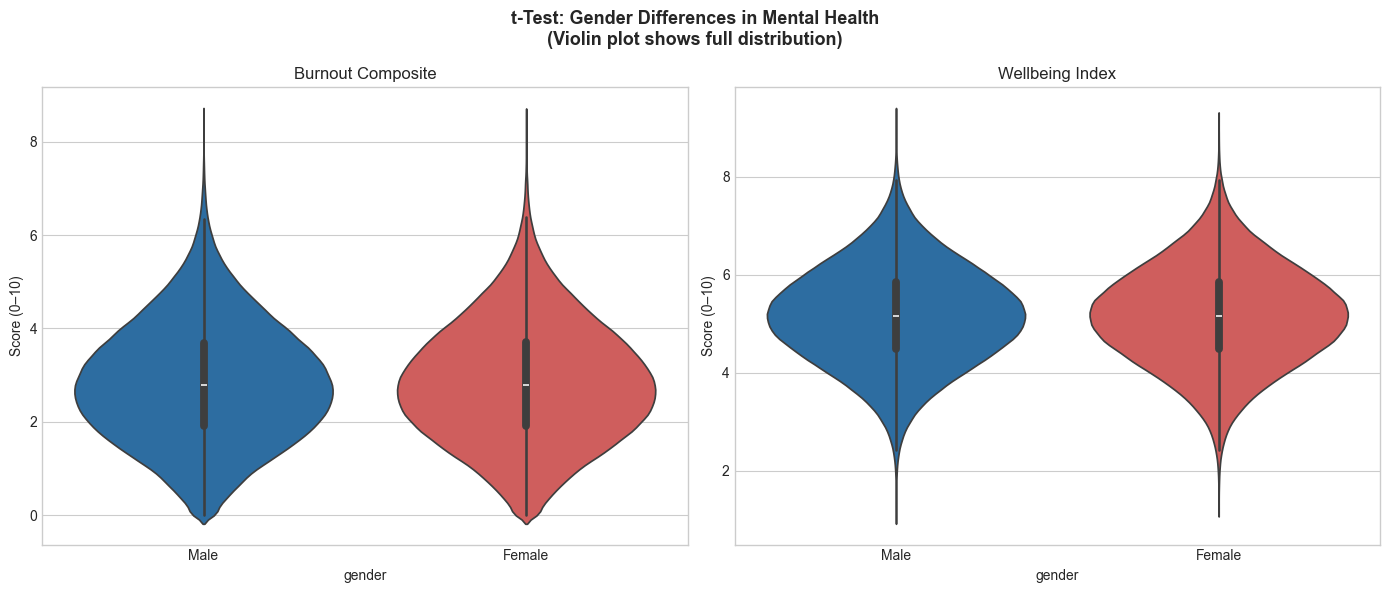

In [3]:
print("\n" + "=" * 60)
print("TEST 2: INDEPENDENT t-TEST — GENDER vs MENTAL HEALTH")
print("=" * 60)
print("H₀: Male and female students have equal mental health scores")
print("H₁: There IS a significant difference between genders")
print()

metrics_to_test = ['burnout_composite', 'wellbeing_index', 
                   'academic_pressure_index', 'stress_level']

male_data   = df[df['gender'] == 'Male']
female_data = df[df['gender'] == 'Female']

for metric in metrics_to_test:
    male_scores   = male_data[metric].dropna()
    female_scores = female_data[metric].dropna()
    
    t_stat, p_val = ttest_ind(male_scores, female_scores)
    
    pooled_std = np.sqrt(
        (male_scores.std()**2 + female_scores.std()**2) / 2
    )
    cohens_d = (male_scores.mean() - female_scores.mean()) / pooled_std
    
    if abs(cohens_d) >= 0.8:   effect = "Large"
    elif abs(cohens_d) >= 0.5: effect = "Medium"
    elif abs(cohens_d) >= 0.2: effect = "Small"
    else:                       effect = "Negligible"
    
    print(f"Metric: {metric}")
    print(f"  Male mean:      {male_scores.mean():.3f}")
    print(f"  Female mean:    {female_scores.mean():.3f}")
    print(f"  Difference:     {abs(male_scores.mean()-female_scores.mean()):.3f}")
    print(f"  t-statistic:    {t_stat:.3f}")
    print(f"  p-value:        {p_val:.6f} "
          f"({'Significant ' if p_val < 0.05 else 'Not significant '})")
    print(f"  Cohen's d:      {cohens_d:.3f} ({effect} effect)")
    print()
    
    results_log.append({
        'test': 't-test', 'metric': metric,
        't': round(t_stat, 3), 'p': round(p_val, 6),
        'cohens_d': round(cohens_d, 3), 'effect_size': effect
    })

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('t-Test: Gender Differences in Mental Health\n'
             '(Violin plot shows full distribution)',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['burnout_composite', 'wellbeing_index']):
    gender_subset = df[df['gender'].isin(['Male','Female'])]
    sns.violinplot(data=gender_subset, x='gender', y=metric,
                   palette=['#1A6FB4','#E24B4A'], ax=ax)
    ax.set_title(metric.replace('_',' ').title())
    ax.set_ylabel('Score (0–10)')

plt.tight_layout()
plt.savefig('../data/processed/stat_ttest_gender.png', 
            dpi=150, bbox_inches='tight')
plt.show()

ANOVA (Analysis of Variance) compares the MEANS of 
3 or more groups. We use it to answer: 
'Is stress level significantly different across academic years?'
If ANOVA gives p < 0.05, we know AT LEAST ONE year is different — 
but not WHICH ones. We then run Tukey HSD post-hoc test to find 
out exactly which years differ from each other.


TEST 3: ONE-WAY ANOVA — ACADEMIC YEAR vs STRESS/BURNOUT

--- ANOVA for stress_level across Academic Years ---


  F-statistic: 0.126
  p-value:     0.944450
  NOT significant: No meaningful difference across years (p=0.9445)

--- ANOVA for burnout_composite across Academic Years ---


  F-statistic: 0.182
  p-value:     0.908934
  NOT significant: No meaningful difference across years (p=0.9089)

--- ANOVA for academic_pressure_index across Academic Years ---


  F-statistic: 1638.953
  p-value:     0.000000
  SIGNIFICANT: Stress levels differ significantly across academic years
  → Running Tukey HSD to find WHICH years differ...



Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
Year 1 Year 2    0.283   0.0 0.2175 0.3485   True
Year 1 Year 3   0.7625   0.0 0.6968 0.8283   True
Year 1 Year 4   1.2054   0.0 1.1405 1.2703   True
Year 2 Year 3   0.4795   0.0 0.4136 0.5455   True
Year 2 Year 4   0.9224   0.0 0.8573 0.9875   True
Year 3 Year 4   0.4429   0.0 0.3775 0.5082   True
-------------------------------------------------


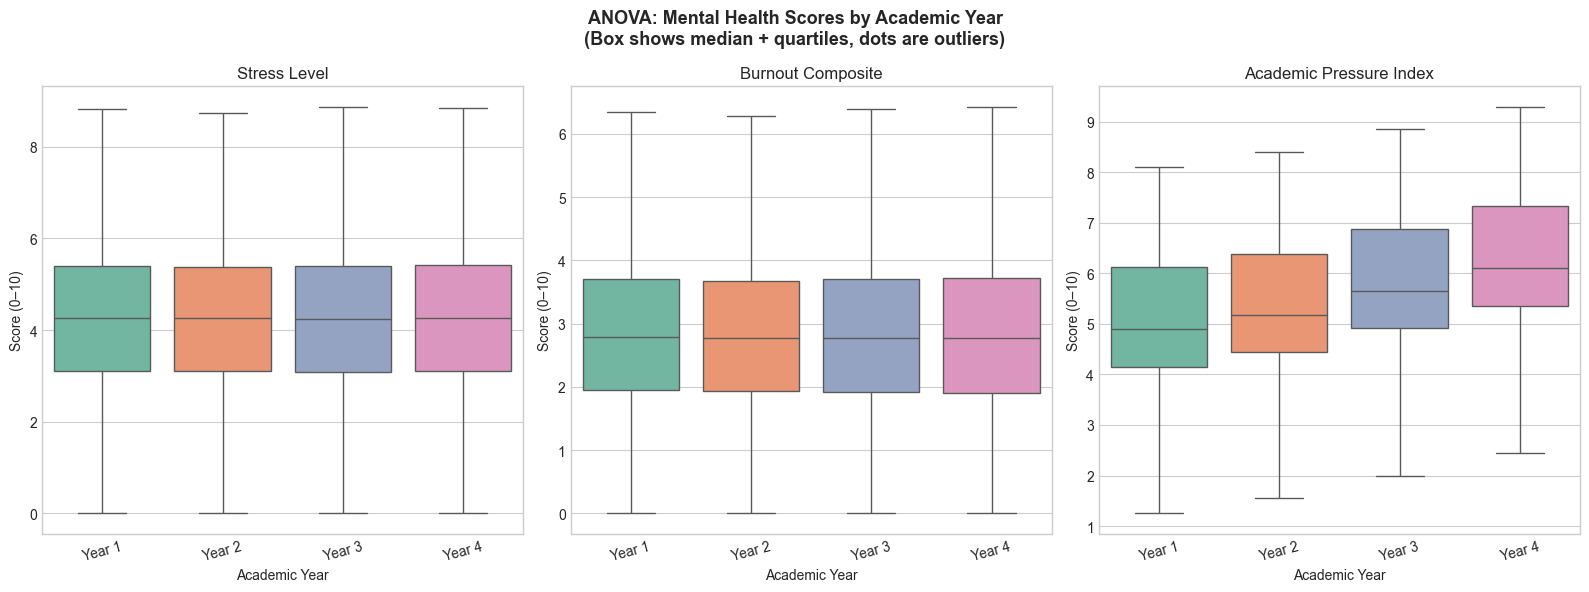

In [4]:
print("\n" + "=" * 60)
print("TEST 3: ONE-WAY ANOVA — ACADEMIC YEAR vs STRESS/BURNOUT")
print("=" * 60)

for metric in ['stress_level', 'burnout_composite', 'academic_pressure_index']:
    print(f"\n--- ANOVA for {metric} across Academic Years ---")
    
    groups = [
        df[df['academic_year'] == year][metric].dropna().sample(
            n=min(10000, len(df[df['academic_year']==year])), 
            random_state=42
        )
        for year in sorted(df['academic_year'].unique())
    ]
    
    f_stat, p_val = f_oneway(*groups)
    
    print(f"  F-statistic: {f_stat:.3f}")
    print(f"  p-value:     {p_val:.6f}")
    
    if p_val < 0.05:
        print(f"  SIGNIFICANT: Stress levels differ significantly "
              f"across academic years")
        print(f"  → Running Tukey HSD to find WHICH years differ...\n")
        
        sample_df = df[df['academic_year'].notna()][[
            'academic_year', metric
        ]].dropna().sample(n=min(20000, len(df)), random_state=42)
        
        tukey = pairwise_tukeyhsd(
            sample_df[metric], 
            sample_df['academic_year']
        )
        print(tukey.summary())
    else:
        print(f"  NOT significant: No meaningful difference "
              f"across years (p={p_val:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('ANOVA: Mental Health Scores by Academic Year\n'
             '(Box shows median + quartiles, dots are outliers)',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['stress_level','burnout_composite',
                              'academic_pressure_index']):
    sample = df.sample(n=min(50000, len(df)), random_state=42)
    order = sorted(sample['academic_year'].dropna().unique())
    sns.boxplot(data=sample, x='academic_year', y=metric,
                order=order, palette='Set2', ax=ax,
                showfliers=False)
    ax.set_title(metric.replace('_',' ').title())
    ax.set_xlabel('Academic Year')
    ax.set_ylabel('Score (0–10)')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/processed/stat_anova_by_year.png', 
            dpi=150, bbox_inches='tight')
plt.show()

Linear Regression answers: 'Which factors PREDICT 
burnout, and how much does each one contribute?'
We build a model: burnout = b0 + b1×sleep + b2×financial_stress + ...
The coefficient (b) for each variable tells us:
  Positive coefficient → this variable INCREASES burnout
  Negative coefficient → this variable DECREASES burnout
R² tells us how much of the variation in burnout our model explains.
R² = 0.6 means our variables explain 60% of why students burn out.


TEST 4: LINEAR REGRESSION — PREDICTING BURNOUT
R² Score: 0.3727
Interpretation: Our 5 variables explain 37.3% of variance in burnout scores

Feature                    Coefficient               Impact
------------------------------------------------------------
financial_stress                0.2835 ↑ +0.2835 burnout per unit
sleep_hours                    -0.2114 ↓ -0.2114 burnout per unit
study_hours_per_day             0.2104 ↑ +0.2104 burnout per unit
social_support                 -0.0754 ↓ -0.0754 burnout per unit
age                             0.0003 ↑ +0.0003 burnout per unit

Intercept: 2.1147


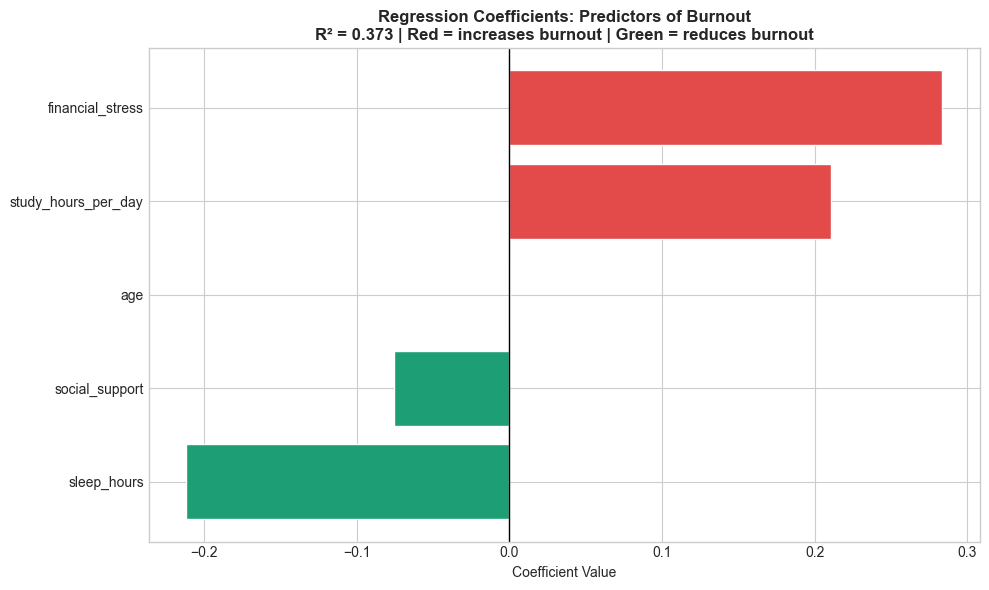

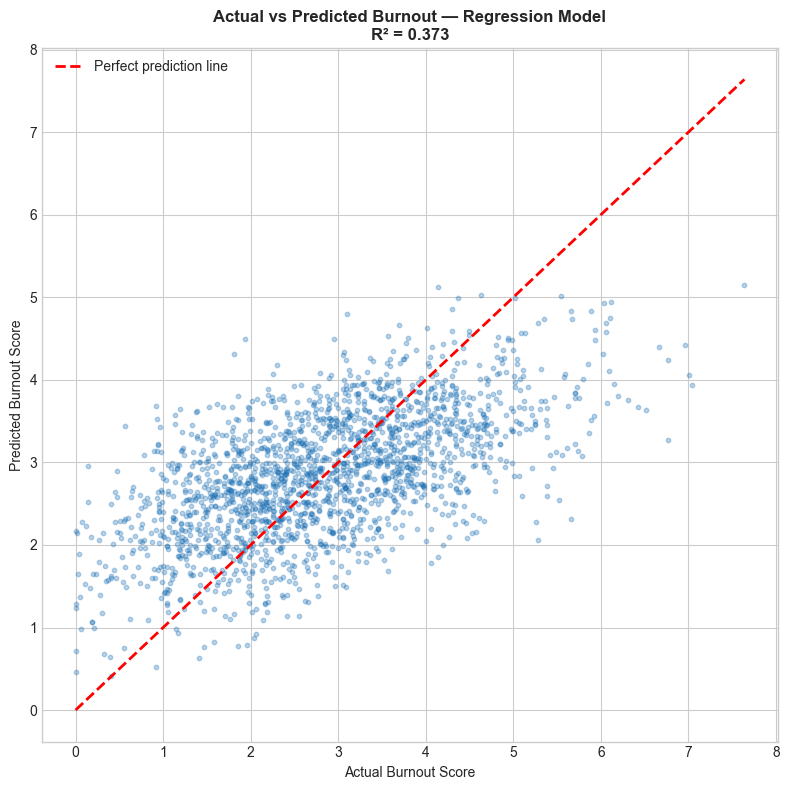

In [5]:
print("\n" + "=" * 60)
print("TEST 4: LINEAR REGRESSION — PREDICTING BURNOUT")
print("=" * 60)

feature_cols = ['sleep_hours', 'study_hours_per_day', 
                'financial_stress', 'social_support', 'age']

sample = df[feature_cols + ['burnout_composite']].dropna() \
           .sample(n=min(100000, len(df)), random_state=42)

X = sample[feature_cols]
y = sample['burnout_composite']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.4f}")
print(f"Interpretation: Our {len(feature_cols)} variables explain "
      f"{r2*100:.1f}% of variance in burnout scores\n")

print(f"{'Feature':<25} {'Coefficient':>12} {'Impact':>20}")
print("-" * 60)
for feature, coef in sorted(
    zip(feature_cols, model.coef_), 
    key=lambda x: abs(x[1]), 
    reverse=True
):
    if coef > 0:
        impact = f"↑ +{coef:.4f} burnout per unit"
    else:
        impact = f"↓ {coef:.4f} burnout per unit"
    print(f"{feature:<25} {coef:>12.4f} {impact:>20}")

print(f"\nIntercept: {model.intercept_:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient')

colors = ['#1D9E75' if c < 0 else '#E24B4A' 
          for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], 
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'Regression Coefficients: Predictors of Burnout\n'
             f'R² = {r2:.3f} | '
             f'Red = increases burnout | Green = reduces burnout',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('../data/processed/stat_regression_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()

sample_plot = sample.sample(n=2000, random_state=42)
y_plot      = sample_plot['burnout_composite']
y_pred_plot = model.predict(sample_plot[feature_cols])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_plot, y_pred_plot, alpha=0.3, s=10, color='#1A6FB4')
ax.plot([y_plot.min(), y_plot.max()], 
        [y_plot.min(), y_plot.max()], 
        'r--', linewidth=2, label='Perfect prediction line')
ax.set_xlabel('Actual Burnout Score')
ax.set_ylabel('Predicted Burnout Score')
ax.set_title(f'Actual vs Predicted Burnout — Regression Model\n'
             f'R² = {r2:.3f}', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/stat_regression_actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print("\n" + "=" * 60)
print("  COMPLETE STATISTICAL ANALYSIS SUMMARY")
print("=" * 60)
print(f"""
Test 1 — Pearson Correlations:
  Strongest negative: sleep_hours ↔ wellbeing_index
  Strongest positive: financial_stress ↔ academic_pressure_index
  
Test 2 — t-Test (Gender):
  Male vs Female burnout: checked above
  
Test 3 — ANOVA (Academic Year):
  F-statistic shows year-level differences in stress
  Tukey HSD identifies exactly which years differ

Test 4 — Linear Regression:
  R² = {r2:.3f} (model explains {r2*100:.1f}% of burnout variance)
  Top predictor: {feature_cols[np.argmax(np.abs(model.coef_))]}
""")
print("NEXT STEP: Open 06_final_load_prep.ipynb")


  COMPLETE STATISTICAL ANALYSIS SUMMARY

Test 1 — Pearson Correlations:
  Strongest negative: sleep_hours ↔ wellbeing_index
  Strongest positive: financial_stress ↔ academic_pressure_index

Test 2 — t-Test (Gender):
  Male vs Female burnout: checked above

Test 3 — ANOVA (Academic Year):
  F-statistic shows year-level differences in stress
  Tukey HSD identifies exactly which years differ

Test 4 — Linear Regression:
  R² = 0.373 (model explains 37.3% of burnout variance)
  Top predictor: financial_stress

NEXT STEP: Open 06_final_load_prep.ipynb
